# Freddie Mac Multi-Year Performance Target Validation

## Purpose

This notebook applies the validated 2015 performance-target methodology
consistently to the 2015–2023 Freddie Mac annual samples. It follows the same
reusable-pipeline, annual-summary, cross-year-comparison, persistence, and
read-back pattern used in Notebook 03.

The expanded window supports the agreed temporal design: 2015–2019 for model
development, 2020 for temporal validation, 2021 for temporal testing, and
2022–2023 for post-deployment monitoring.

The target definition is fixed before cross-year processing:

- **90+ serious delinquency:** numeric delinquency status 3 or higher, plus
  `RA`;
- **terminal credit event:** Zero Balance Code `02`, `03`, `09`, or
  `15`;
- **composite outcome:** either serious delinquency or a terminal credit event;
- **primary horizon:** months 0 through 23 from `FIRST PAYMENT DATE`;
- **eligibility:** history begins no later than month 0 and follow-up is
  complete through the horizon or a documented termination; and
- **coverage guard:** at least 95% follow-up coverage among loans observable
  from month 0.

The 12- and 36-month candidates remain available for sensitivity analysis,
subject to their own follow-up maturity. Overall sample retention is reported
separately so left truncation remains visible.

### Documentation basis

- [Freddie Mac Single-Family Loan-Level Dataset General User Guide](https://www.freddiemac.com/fmac-resources/research/pdf/user_guide.pdf)
- [Freddie Mac Non-Standard Dataset Summary Statistics](https://www.freddiemac.com/fmac-resources/research/pdf/nonstandard_dataset_summary_statistics.pdf)

The delinquency and termination meanings come from Freddie Mac documentation.
The 24-month horizon and 95% observable-cohort coverage threshold are project
methodology choices.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.freddie_performance import (
    CREDIT_EVENT_ZERO_BALANCE_CODES,
)
from src.freddie_performance_pipeline import (
    combine_performance_targets,
    run_performance_target_pipeline,
)


print("Notebook directory:", CURRENT_DIRECTORY)
print("Project root:", PROJECT_ROOT)

Notebook directory: e:\capstone_project\mortgage-model-reliability\notebooks
Project root: e:\capstone_project\mortgage-model-reliability


## 1. Multi-Year File Configuration

Define the study window, candidate horizons, selected horizon, coverage threshold, and all file locations once. Every later processing and validation cell uses these shared settings.

Both supported performance filenames are checked because the locally extracted sample files use `sample_perf_YEAR.txt`, while some Freddie Mac releases use `sample_svcg_YEAR.txt`.

In [2]:
YEARS = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
HORIZONS = (12, 24, 36)
SELECTED_HORIZON = 24
MINIMUM_OBSERVABLE_COVERAGE_PERCENTAGE = 95.0
EXPECTED_LOANS_PER_YEAR = 50000

RAW_DATA_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Freddie_Mac"
)
PROCESSED_DATA_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "Freddie_Mac"
)

PERFORMANCE_FILE_CANDIDATES = {
    year: [
        (
            RAW_DATA_DIRECTORY
            / f"sample_{year}"
            / f"sample_svcg_{year}.txt"
        ),
        (
            RAW_DATA_DIRECTORY
            / f"sample_{year}"
            / f"sample_perf_{year}.txt"
        ),
    ]
    for year in YEARS
}

PERFORMANCE_FILES = {}
ORIGINATION_FILES = {}
file_check_rows = []

for year in YEARS:
    existing_performance_files = [
        path
        for path in PERFORMANCE_FILE_CANDIDATES[year]
        if path.exists()
    ]
    performance_file = (
        existing_performance_files[0]
        if existing_performance_files
        else PERFORMANCE_FILE_CANDIDATES[year][0]
    )
    origination_file = (
        PROCESSED_DATA_DIRECTORY
        / f"origination_{year}_clean.parquet"
    )

    PERFORMANCE_FILES[year] = performance_file
    ORIGINATION_FILES[year] = origination_file

    file_check_rows.extend(
        [
            {
                "year": year,
                "file_type": "raw_performance",
                "exists": performance_file.exists(),
                "path": str(performance_file),
            },
            {
                "year": year,
                "file_type": "cleaned_origination",
                "exists": origination_file.exists(),
                "path": str(origination_file),
            },
        ]
    )

file_check = pd.DataFrame(file_check_rows)
display(file_check)

missing_files = file_check.loc[
    ~file_check["exists"],
    "path",
].tolist()

if missing_files:
    raise FileNotFoundError(
        "Missing multi-year target inputs: "
        f"{missing_files}"
    )

,year,file_type,exists,path
0,2015,raw_performance,True,e:\capstone_project\mortgage-model-reliability...
1,2015,cleaned_origination,True,e:\capstone_project\mortgage-model-reliability...
2,2016,raw_performance,True,e:\capstone_project\mortgage-model-reliability...
3,2016,cleaned_origination,True,e:\capstone_project\mortgage-model-reliability...
4,2017,raw_performance,True,e:\capstone_project\mortgage-model-reliability...
5,2017,cleaned_origination,True,e:\capstone_project\mortgage-model-reliability...
6,2018,raw_performance,True,e:\capstone_project\mortgage-model-reliability...
7,2018,cleaned_origination,True,e:\capstone_project\mortgage-model-reliability...
8,2019,raw_performance,True,e:\capstone_project\mortgage-model-reliability...
9,2019,cleaned_origination,True,e:\capstone_project\mortgage-model-reliability...


## 2. Confirm the Fixed Target Contract

Display the project decisions before processing any year. These definitions
must remain identical across 2015–2023 so differences in event rates are not
caused by changing label logic.

Terminal codes supplement the delinquency outcome; they are not silently
substituted for it. Codes `01`, `16`, and `96` remain valid termination
reasons but do not independently create a positive outcome.

In [3]:
target_contract = pd.DataFrame(
    [
        {
            "setting": "Study years",
            "value": ", ".join(map(str, YEARS)),
        },
        {
            "setting": "Candidate horizons",
            "value": ", ".join(map(str, HORIZONS)),
        },
        {
            "setting": "Primary horizon",
            "value": f"{SELECTED_HORIZON} months",
        },
        {
            "setting": "Serious delinquency",
            "value": "Numeric status >= 3 or RA",
        },
        {
            "setting": "Terminal credit codes",
            "value": ", ".join(
                sorted(CREDIT_EVENT_ZERO_BALANCE_CODES)
            ),
        },
        {
            "setting": "Coverage denominator",
            "value": "Loans observable from month 0",
        },
        {
            "setting": "Minimum coverage",
            "value": (
                f"{MINIMUM_OBSERVABLE_COVERAGE_PERCENTAGE:.1f}%"
            ),
        },
    ]
)

display(target_contract)

,setting,value
0,Study years,"2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022..."
1,Candidate horizons,"12, 24, 36"
2,Primary horizon,24 months
3,Serious delinquency,Numeric status >= 3 or RA
4,Terminal credit codes,"02, 03, 09, 15"
5,Coverage denominator,Loans observable from month 0
6,Minimum coverage,95.0%


## 3. Run the Reusable Annual Performance Pipeline

Process one annual sample at a time to control memory use. Each run:

1. scans every raw row for the expected 35-field structure;
2. loads only the five fields needed to create the outcome;
3. validates identifiers, periods, codes, duplicates, and origination linkage;
4. builds the first-payment-relative timeline;
5. creates 12-, 24-, and 36-month candidates;
6. applies the observable-cohort coverage guard;
7. saves annual target, horizon, component, cohort, and validation outputs; and
8. reads every analytical output back for verification.

If a year fails a critical validation or the 95% guard, processing stops at that year.

In [4]:
pipeline_results = {}

for year in YEARS:
    print("=" * 72)
    print(f"Processing performance target for {year}")

    pipeline_result = run_performance_target_pipeline(
        year=year,
        performance_file=PERFORMANCE_FILES[year],
        origination_file=ORIGINATION_FILES[year],
        output_directory=PROCESSED_DATA_DIRECTORY,
        horizons=HORIZONS,
        selected_horizon=SELECTED_HORIZON,
        minimum_observable_coverage_percentage=(
            MINIMUM_OBSERVABLE_COVERAGE_PERCENTAGE
        ),
        expected_loans=EXPECTED_LOANS_PER_YEAR,
    )

    pipeline_results[year] = pipeline_result

    selected = pipeline_result["selected_summary"]

    print(
        "Performance rows:",
        pipeline_result["validation"]["performance_rows"],
    )
    print(
        "Eligible loans:",
        int(selected["eligible_loans"]),
    )
    print(
        "Observable-cohort coverage:",
        f"{selected['observable_cohort_coverage_percentage']:.3f}%",
    )
    print(
        "Composite events:",
        int(selected["composite_credit_events"]),
    )

Processing performance target for 2015
Performance rows: 3467166
Eligible loans: 47244
Observable-cohort coverage: 99.958%
Composite events: 248
Processing performance target for 2016
Performance rows: 3379650
Eligible loans: 48076
Observable-cohort coverage: 99.963%
Composite events: 324
Processing performance target for 2017
Performance rows: 2800219
Eligible loans: 48278
Observable-cohort coverage: 99.942%
Composite events: 391
Processing performance target for 2018
Performance rows: 2059564
Eligible loans: 47417
Observable-cohort coverage: 99.905%
Composite events: 1222
Processing performance target for 2019
Performance rows: 1934614
Eligible loans: 48611
Observable-cohort coverage: 99.938%
Composite events: 2227
Processing performance target for 2020
Performance rows: 2517857
Eligible loans: 49665
Observable-cohort coverage: 99.964%
Composite events: 802
Processing performance target for 2021
Performance rows: 2537054
Eligible loans: 49490
Observable-cohort coverage: 99.956%
Compo

## 4. Review Annual Structure and Linkage Validation

Combine the lightweight validation reports returned by each annual run. The expected result is one row per year, zero structural errors, 50,000 performance loans matched to 50,000 cleaned origination loans, and no critical key or code violations.

In [5]:
validation_rows = []

for year in YEARS:
    result = pipeline_results[year]

    validation_rows.append(
        {
            "year": year,
            **result["structure_validation"],
            **result["validation"],
        }
    )

annual_validation = pd.DataFrame(validation_rows)
display(annual_validation)

,year,rows_scanned,expected_fields_per_row,field_count_errors,performance_rows,performance_columns_loaded,performance_loans,origination_loans,missing_loan_ids,invalid_periods,duplicate_loan_periods,unexpected_delinquency_statuses,unexpected_zero_balance_codes,unmatched_performance_loans,origination_loans_without_performance
0,2015,3467166,35,0,3467166,5,50000,50000,0,0,0,0,0,0,0
1,2016,3379650,35,0,3379650,5,50000,50000,0,0,0,0,0,0,0
2,2017,2800219,35,0,2800219,5,50000,50000,0,0,0,0,0,0,0
3,2018,2059564,35,0,2059564,5,50000,50000,0,0,0,0,0,0,0
4,2019,1934614,35,0,1934614,5,50000,50000,0,0,0,0,0,0,0
5,2020,2517857,35,0,2517857,5,50000,50000,0,0,0,0,0,0,0
6,2021,2537054,35,0,2537054,5,50000,50000,0,0,0,0,0,0,0
7,2022,2034798,35,0,2034798,5,50000,50000,0,0,0,0,0,0,0
8,2023,1458169,35,0,1458169,5,50000,50000,0,0,0,0,0,0,0


## 5. Enforce Cross-Year Critical Checks

A successful function call is supplemented by explicit notebook assertions. These checks prevent a partially valid annual result from entering the combined target.

Origination loans without performance are reported separately because they are an eligibility limitation; all other listed fields are critical errors and must be zero.

In [6]:
critical_zero_columns = [
    "field_count_errors",
    "missing_loan_ids",
    "invalid_periods",
    "duplicate_loan_periods",
    "unexpected_delinquency_statuses",
    "unexpected_zero_balance_codes",
    "unmatched_performance_loans",
]

for column in critical_zero_columns:
    assert annual_validation[column].eq(0).all(), (
        f"Critical validation failures found in {column}."
    )

assert annual_validation[
    "performance_loans"
].eq(EXPECTED_LOANS_PER_YEAR).all(), (
    "A performance file does not contain 50,000 loans."
)

assert annual_validation[
    "origination_loans"
].eq(EXPECTED_LOANS_PER_YEAR).all(), (
    "A cleaned origination file does not contain 50,000 loans."
)

display(
    annual_validation[
        [
            "year",
            *critical_zero_columns,
            "origination_loans_without_performance",
        ]
    ]
)

,year,field_count_errors,missing_loan_ids,invalid_periods,duplicate_loan_periods,unexpected_delinquency_statuses,unexpected_zero_balance_codes,unmatched_performance_loans,origination_loans_without_performance
0,2015,0,0,0,0,0,0,0,0
1,2016,0,0,0,0,0,0,0,0
2,2017,0,0,0,0,0,0,0,0
3,2018,0,0,0,0,0,0,0,0
4,2019,0,0,0,0,0,0,0,0
5,2020,0,0,0,0,0,0,0,0
6,2021,0,0,0,0,0,0,0,0
7,2022,0,0,0,0,0,0,0,0
8,2023,0,0,0,0,0,0,0,0


## 6. Compare 12-, 24-, and 36-Month Horizons Across Years

Combine the annual horizon summaries without pooling away the year. For every
year and horizon, retain:

- overall sample retention;
- left-truncated loan count;
- observable-cohort size;
- incomplete follow-up;
- observable-cohort coverage;
- serious-delinquency events; and
- composite credit events and rates.

This makes changes in both target prevalence and target availability visible.
The primary 24-month result must be distinguished from sensitivity horizons:
the saved results show adequate 24-month follow-up through 2023, whereas the
2023 36-month cohort is not yet fully mature.

In [7]:
multi_year_horizon_summary = pd.concat(
    [
        pipeline_results[year]["horizon_summary"]
        for year in YEARS
    ],
    ignore_index=True,
)

rate_columns = [
    "serious_delinquency_rate",
    "composite_credit_event_rate",
]

horizon_summary_display = (
    multi_year_horizon_summary.copy()
)

for column in rate_columns:
    horizon_summary_display[
        f"{column}_percentage"
    ] = horizon_summary_display[column] * 100

display(
    horizon_summary_display.drop(
        columns=rate_columns
    ).round(3)
)

,year,horizon_months,total_loans,eligible_loans,sample_retention_percentage,left_truncated_loans,observable_cohort_loans,incomplete_follow_up_loans,observable_cohort_coverage_percentage,serious_delinquency_events,composite_credit_events,serious_delinquency_rate_percentage,composite_credit_event_rate_percentage
0,2015,12,50000,47244,94.488,2736,47264,20,99.958,65,65,0.138,0.138
1,2015,24,50000,47244,94.488,2736,47264,20,99.958,248,248,0.525,0.525
2,2015,36,50000,47244,94.488,2736,47264,20,99.958,444,444,0.940,0.940
3,2016,12,50000,48076,96.152,1906,48094,18,99.963,73,73,0.152,0.152
4,2016,24,50000,48076,96.152,1906,48094,18,99.963,324,324,0.674,0.674
5,2016,36,50000,48076,96.152,1906,48094,18,99.963,477,477,0.992,0.992
6,2017,12,50000,48278,96.556,1694,48306,28,99.942,188,188,0.389,0.389
7,2017,24,50000,48278,96.556,1694,48306,28,99.942,391,391,0.810,0.810
8,2017,36,50000,48278,96.556,1694,48306,28,99.942,1624,1624,3.364,3.364
9,2018,12,50000,47417,94.834,2538,47462,45,99.905,100,100,0.211,0.211


## 7. Verify the 24-Month Coverage Guard for Every Year

Select the primary horizon and verify that each annual observable cohort
exceeds the pre-specified 95% follow-up requirement. All nine 24-month cohorts
pass, including 2023 with 99.792% observable-cohort coverage.

Overall retention is not used as the guard because it includes structurally
left-truncated loans. It remains reported beside coverage so the excluded share
is fully auditable. This check validates the primary target only; it does not
override the incomplete 2023 36-month sensitivity horizon.

In [8]:
selected_horizon_summary = (
    multi_year_horizon_summary.loc[
        multi_year_horizon_summary[
            "horizon_months"
        ].eq(SELECTED_HORIZON)
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

coverage_columns = [
    "year",
    "total_loans",
    "left_truncated_loans",
    "observable_cohort_loans",
    "incomplete_follow_up_loans",
    "eligible_loans",
    "sample_retention_percentage",
    "observable_cohort_coverage_percentage",
]

display(
    selected_horizon_summary[
        coverage_columns
    ].round(3)
)

assert selected_horizon_summary[
    "observable_cohort_coverage_percentage"
].ge(
    MINIMUM_OBSERVABLE_COVERAGE_PERCENTAGE
).all(), (
    "At least one annual 24-month target failed "
    "the observable-cohort coverage guard."
)

,year,total_loans,left_truncated_loans,observable_cohort_loans,incomplete_follow_up_loans,eligible_loans,sample_retention_percentage,observable_cohort_coverage_percentage
0,2015,50000,2736,47264,20,47244,94.488,99.958
1,2016,50000,1906,48094,18,48076,96.152,99.963
2,2017,50000,1694,48306,28,48278,96.556,99.942
3,2018,50000,2538,47462,45,47417,94.834,99.905
4,2019,50000,1359,48641,30,48611,97.222,99.938
5,2020,50000,317,49683,18,49665,99.330,99.964
6,2021,50000,488,49512,22,49490,98.980,99.956
7,2022,50000,554,49446,60,49386,98.772,99.879
8,2023,50000,396,49604,103,49501,99.002,99.792


## 8. Compare Composite-Target Components

Display the four mutually exclusive outcome components for each year:

1. 90+ delinquency only;
2. terminal credit event only;
3. both components; and
4. neither component.

The terminal-only row measures exactly how many positives the composite adds beyond observed delinquency status.

In [9]:
multi_year_component_summary = pd.concat(
    [
        pipeline_results[year]["component_summary"]
        for year in YEARS
    ],
    ignore_index=True,
)

display(
    multi_year_component_summary.round(3)
)

component_reconciliation = (
    multi_year_component_summary.groupby(
        "year",
        as_index=False,
    )
    .agg(component_loans=("loans", "sum"))
    .merge(
        selected_horizon_summary[
            ["year", "eligible_loans"]
        ],
        on="year",
        how="left",
        validate="one_to_one",
    )
)

component_reconciliation["counts_match"] = (
    component_reconciliation["component_loans"]
    == component_reconciliation["eligible_loans"]
)

display(component_reconciliation)

assert component_reconciliation[
    "counts_match"
].all(), "Component counts do not reconcile."

,year,component,loans,percentage
0,2015,90+ delinquency only,233,0.493
1,2015,Terminal credit event only,0,0.000
2,2015,Both components,15,0.032
3,2015,Neither component,46996,99.475
4,2016,90+ delinquency only,315,0.655
5,2016,Terminal credit event only,0,0.000
6,2016,Both components,9,0.019
7,2016,Neither component,47752,99.326
8,2017,90+ delinquency only,374,0.775
9,2017,Terminal credit event only,0,0.000


,year,component_loans,eligible_loans,counts_match
0,2015,47244,47244,True
1,2016,48076,48076,True
2,2017,48278,48278,True
3,2018,47417,47417,True
4,2019,48611,48611,True
5,2020,49665,49665,True
6,2021,49490,49490,True
7,2022,49386,49386,True
8,2023,49501,49501,True


## 9. Visualize Annual Coverage and 24-Month Event Rates

The left panel separates overall sample retention from observable-cohort
follow-up coverage. The right panel compares the annual 90+ and composite event
rates.

The expanded plot covers materially different outcome regimes. The 2019 cohort
has the highest annual 24-month rate (4.581%) and its observation window
overlaps the pandemic onset. The rate falls to 1.615% for 2020 and 0.911% for
2021, then rises to 1.828% in 2022 and remains 1.770% in 2023.

These are descriptive outcome shifts. Their timing makes them relevant to the
reliability study, but they do not by themselves demonstrate borrower-feature
drift, reduced discrimination, calibration failure, or a need to retrain.

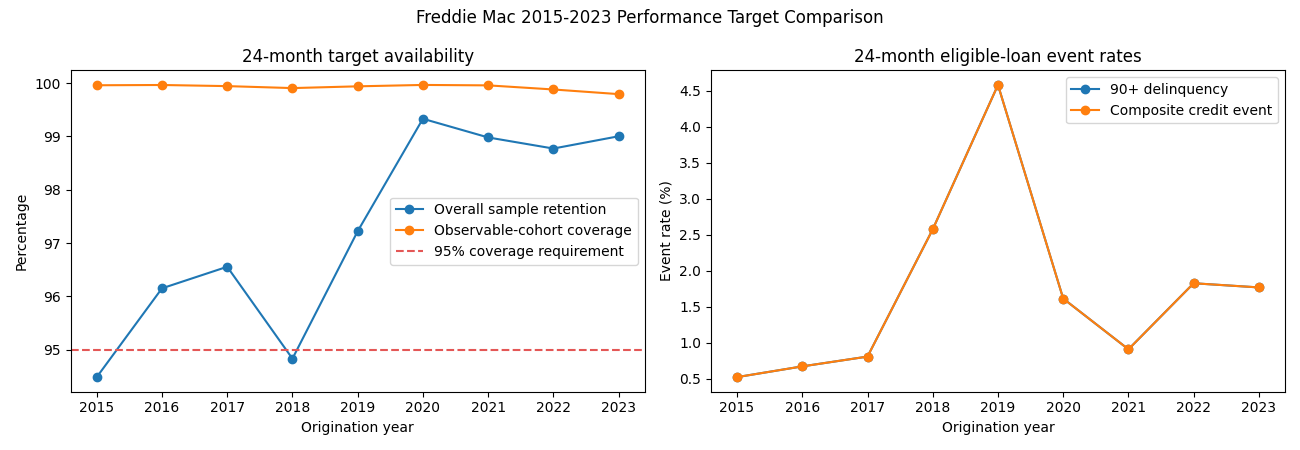

In [10]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.5),
)

year_labels = selected_horizon_summary[
    "year"
].astype(str)

axes[0].plot(
    year_labels,
    selected_horizon_summary[
        "sample_retention_percentage"
    ],
    marker="o",
    label="Overall sample retention",
)
axes[0].plot(
    year_labels,
    selected_horizon_summary[
        "observable_cohort_coverage_percentage"
    ],
    marker="o",
    label="Observable-cohort coverage",
)
axes[0].axhline(
    MINIMUM_OBSERVABLE_COVERAGE_PERCENTAGE,
    color="#E45756",
    linestyle="--",
    label="95% coverage requirement",
)
axes[0].set_title("24-month target availability")
axes[0].set_xlabel("Origination year")
axes[0].set_ylabel("Percentage")
axes[0].legend()

axes[1].plot(
    year_labels,
    selected_horizon_summary[
        "serious_delinquency_rate"
    ] * 100,
    marker="o",
    label="90+ delinquency",
)
axes[1].plot(
    year_labels,
    selected_horizon_summary[
        "composite_credit_event_rate"
    ] * 100,
    marker="o",
    label="Composite credit event",
)
axes[1].set_title("24-month eligible-loan event rates")
axes[1].set_xlabel("Origination year")
axes[1].set_ylabel("Event rate (%)")
axes[1].legend()

figure.suptitle(
    "Freddie Mac 2015-2023 Performance Target Comparison"
)
figure.tight_layout()
plt.show()

## 10. Validate Quarterly Outcome Summaries

Combine the 36 quarterly cohorts from `2015Q1` through `2023Q4`. Verify
that every annual file contributes four quarters and that quarterly eligible
and event counts reconcile to the annual selected-horizon summary.

Quarterly rates expose within-year variation that annual averages can hide.
For example, the 2020Q1 24-month composite rate is 3.807%, compared with
0.724%–1.079% for the remaining 2020 quarters. Event counts and estimate
stability must still be considered before selecting a quarterly, semiannual, or
annual monitoring cadence.

In [11]:
multi_year_quarterly_summary = pd.concat(
    [
        pipeline_results[year]["cohort_summary"]
        for year in YEARS
    ],
    ignore_index=True,
)

quarterly_reconciliation = (
    multi_year_quarterly_summary.groupby(
        "year",
        as_index=False,
    )
    .agg(
        quarter_count=(
            "ORIGINATION COHORT",
            "nunique",
        ),
        quarterly_eligible_loans=(
            "eligible_loans",
            "sum",
        ),
        quarterly_composite_events=(
            "composite_credit_events",
            "sum",
        ),
    )
    .merge(
        selected_horizon_summary[
            [
                "year",
                "eligible_loans",
                "composite_credit_events",
            ]
        ],
        on="year",
        how="left",
        validate="one_to_one",
    )
)

quarterly_reconciliation["eligible_counts_match"] = (
    quarterly_reconciliation[
        "quarterly_eligible_loans"
    ]
    == quarterly_reconciliation["eligible_loans"]
)
quarterly_reconciliation["event_counts_match"] = (
    quarterly_reconciliation[
        "quarterly_composite_events"
    ]
    == quarterly_reconciliation[
        "composite_credit_events"
    ]
)

display(
    multi_year_quarterly_summary.round(3)
)
display(quarterly_reconciliation)

assert quarterly_reconciliation[
    "quarter_count"
].eq(4).all(), "An annual target is missing a quarter."

assert quarterly_reconciliation[
    [
        "eligible_counts_match",
        "event_counts_match",
    ]
].all().all(), "Quarterly counts do not reconcile."

,year,ORIGINATION COHORT,eligible_loans,serious_delinquency_events,serious_delinquency_rate,composite_credit_events,composite_credit_event_rate,serious_delinquency_rate_percentage,composite_credit_event_rate_percentage
0,2015,2015Q1,11803,45,0.004,45,0.004,0.381,0.381
1,2015,2015Q2,11799,42,0.004,42,0.004,0.356,0.356
2,2015,2015Q3,11803,66,0.006,66,0.006,0.559,0.559
3,2015,2015Q4,11839,95,0.008,95,0.008,0.802,0.802
4,2016,2016Q1,12018,69,0.006,69,0.006,0.574,0.574
5,2016,2016Q2,12021,88,0.007,88,0.007,0.732,0.732
6,2016,2016Q3,12123,85,0.007,85,0.007,0.701,0.701
7,2016,2016Q4,11914,82,0.007,82,0.007,0.688,0.688
8,2017,2017Q1,12082,96,0.008,96,0.008,0.795,0.795
9,2017,2017Q2,12009,126,0.01,126,0.01,1.049,1.049


,year,quarter_count,quarterly_eligible_loans,quarterly_composite_events,eligible_loans,composite_credit_events,eligible_counts_match,event_counts_match
0,2015,4,47244,248,47244,248,True,True
1,2016,4,48076,324,48076,324,True,True
2,2017,4,48278,391,48278,391,True,True
3,2018,4,47417,1222,47417,1222,True,True
4,2019,4,48611,2227,48611,2227,True,True
5,2020,4,49665,802,49665,802,True,True
6,2021,4,49490,451,49490,451,True,True
7,2022,4,49386,903,49386,903,True,True
8,2023,4,49501,876,49501,876,True,True


## 11. Visualize the 36 Quarterly Event Rates

Plot the 24-month composite event rate for every origination quarter. This is
the outcome series that will later be compared with borrower-feature drift and
model-reliability measures.

Quarterly variation is an early signal to investigate, not direct proof of
model degradation. Low event counts and uncertainty must be considered before
choosing the final monitoring cadence.

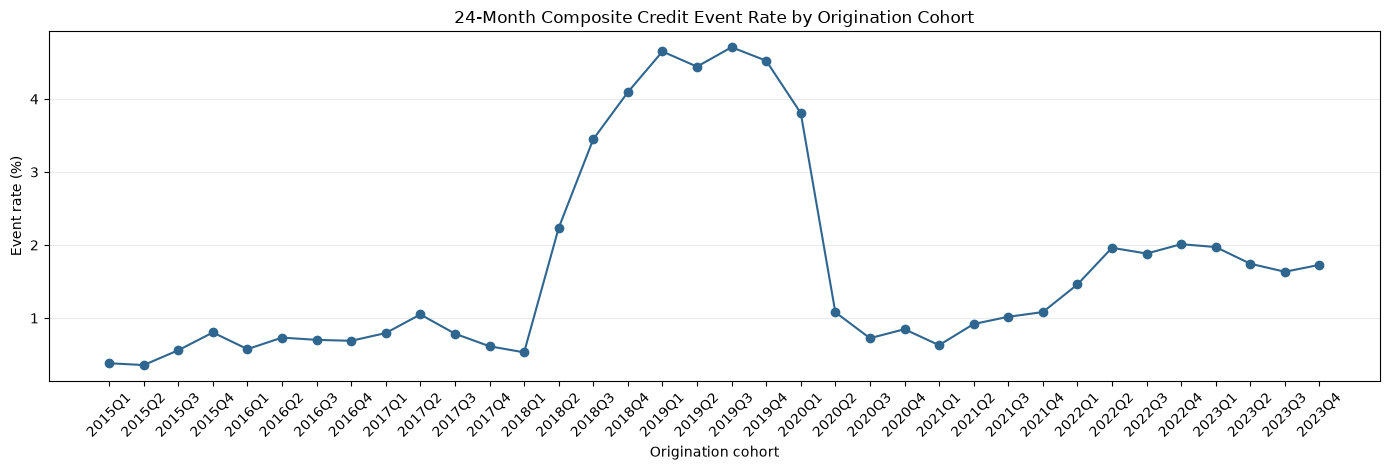

In [12]:
quarterly_plot_data = (
    multi_year_quarterly_summary.sort_values(
        ["year", "ORIGINATION COHORT"]
    )
    .reset_index(drop=True)
)

figure, axis = plt.subplots(figsize=(14, 4.8))

axis.plot(
    quarterly_plot_data["ORIGINATION COHORT"],
    quarterly_plot_data[
        "composite_credit_event_rate_percentage"
    ],
    marker="o",
    color="#2F6690",
)
axis.set_title(
    "24-Month Composite Credit Event Rate by Origination Cohort"
)
axis.set_xlabel("Origination cohort")
axis.set_ylabel("Event rate (%)")
axis.tick_params(axis="x", rotation=45)
axis.grid(axis="y", alpha=0.25)

figure.tight_layout()
plt.show()

## 12. Review Every Annual Read-Back Validation

The annual pipeline reopened each saved candidate Parquet, selected-target Parquet, horizon CSV, cohort CSV, component CSV, and validation JSON.

This table verifies expected candidate rows, unique loan-horizon keys, valid horizons and labels, selected-target uniqueness, summary row counts, count reconciliation, and validation-JSON agreement for each year.

In [13]:
annual_readback_rows = []

for year in YEARS:
    annual_readback_rows.append(
        {
            "year": year,
            **pipeline_results[year][
                "readback_validation"
            ],
        }
    )

annual_readback_summary = pd.DataFrame(
    annual_readback_rows
)

display(annual_readback_summary)

assert annual_readback_summary[
    "candidate_duplicate_loan_horizons"
].eq(0).all()

assert annual_readback_summary[
    "selected_target_duplicate_loans"
].eq(0).all()

assert annual_readback_summary[
    "validation_json_matches"
].all()

,year,candidate_rows,expected_candidate_rows,candidate_duplicate_loan_horizons,unexpected_saved_horizons,selected_target_rows,selected_target_duplicate_loans,unexpected_target_values,selected_horizon_values,saved_horizon_summary_rows,saved_cohort_summary_rows,saved_component_summary_rows,validation_json_matches
0,2015,150000,150000,0,[],47244,0,[],[24],3,4,4,True
1,2016,150000,150000,0,[],48076,0,[],[24],3,4,4,True
2,2017,150000,150000,0,[],48278,0,[],[24],3,4,4,True
3,2018,150000,150000,0,[],47417,0,[],[24],3,4,4,True
4,2019,150000,150000,0,[],48611,0,[],[24],3,4,4,True
5,2020,150000,150000,0,[],49665,0,[],[24],3,4,4,True
6,2021,150000,150000,0,[],49490,0,[],[24],3,4,4,True
7,2022,150000,150000,0,[],49386,0,[],[24],3,4,4,True
8,2023,150000,150000,0,[],49501,0,[],[24],3,4,4,True


## 13. Create the Combined 2015–2023 Modeling Target

After all annual outputs pass, concatenate the nine eligible 24-month target
files. Preserve `SOURCE YEAR` and `ORIGINATION COHORT` so later joins,
temporal splits, and reliability evaluation remain auditable.

The combined function also saves annual and quarterly summaries and performs a
full read-back check.

In [14]:
combined_results = combine_performance_targets(
    years=YEARS,
    output_directory=PROCESSED_DATA_DIRECTORY,
    selected_horizon=SELECTED_HORIZON,
)

print("Combined outputs:")

for output_name, output_path in (
    combined_results["output_paths"].items()
):
    print(f"{output_name}: {output_path}")

Combined outputs:
combined_target: e:\capstone_project\mortgage-model-reliability\data\processed\Freddie_Mac\performance_target_2015_2023_24m.parquet
annual_summary: e:\capstone_project\mortgage-model-reliability\data\processed\Freddie_Mac\performance_target_2015_2023_annual_summary.csv
quarterly_summary: e:\capstone_project\mortgage-model-reliability\data\processed\Freddie_Mac\performance_target_2015_2023_quarterly_summary.csv
validation: e:\capstone_project\mortgage-model-reliability\data\processed\Freddie_Mac\performance_target_2015_2023_validation.json


## 14. Validate the Combined Target and Final Outcome Counts

Confirm that the combined file contains all nine years, only the selected
24-month horizon, no duplicate year-loan keys, nine annual summary rows, and 36
quarterly summary rows.

The validated combined target contains 437,668 eligible loan-year records.
The annual table is the authoritative cross-year target summary for the next
modeling-data join.

In [15]:
combined_target = combined_results[
    "combined_target"
]
combined_annual_summary = combined_results[
    "annual_summary"
]
combined_quarterly_summary = combined_results[
    "quarterly_summary"
]
combined_readback = combined_results[
    "readback_validation"
]

combined_outcome_summary = (
    combined_target.groupby(
        "SOURCE YEAR",
        as_index=False,
    )
    .agg(
        eligible_loans=("LOAN IDENTIFIER", "size"),
        serious_delinquency_events=(
            "TARGET_90_PLUS",
            "sum",
        ),
        composite_credit_events=(
            "TARGET_COMPOSITE_CREDIT_EVENT",
            "sum",
        ),
        composite_event_rate=(
            "TARGET_COMPOSITE_CREDIT_EVENT",
            "mean",
        ),
    )
)

combined_outcome_summary[
    "composite_event_rate_percentage"
] = (
    combined_outcome_summary[
        "composite_event_rate"
    ] * 100
)

display(
    combined_outcome_summary.drop(
        columns="composite_event_rate"
    ).round(3)
)
display(pd.DataFrame([combined_readback]))

assert combined_readback[
    "duplicate_year_loan_rows"
] == 0
assert combined_readback["saved_years"] == YEARS
assert combined_readback[
    "saved_horizons"
] == [SELECTED_HORIZON]
assert combined_readback[
    "annual_summary_rows"
] == len(YEARS)
assert combined_readback[
    "quarterly_summary_rows"
] == len(YEARS) * 4
assert combined_readback[
    "validation_json_matches"
]

,SOURCE YEAR,eligible_loans,serious_delinquency_events,composite_credit_events,composite_event_rate_percentage
0,2015,47244,248,248,0.525
1,2016,48076,324,324,0.674
2,2017,48278,391,391,0.81
3,2018,47417,1222,1222,2.577
4,2019,48611,2227,2227,4.581
5,2020,49665,802,802,1.615
6,2021,49490,451,451,0.911
7,2022,49386,903,903,1.828
8,2023,49501,876,876,1.77


,combined_target_rows,combined_target_columns,duplicate_year_loan_rows,saved_years,saved_horizons,annual_summary_rows,quarterly_summary_rows,validation_json_matches
0,437668,11,0,"[2015, 2016, 2017, 2018, 2019, 2020, 2021, 202...",[24],9,36,True


## 15. Conclusion and Next Stage

This notebook completes the reusable 2015–2023 performance-target milestone.

### Completion criteria

- All 22,189,091 monthly performance rows conform to the expected 35-field
  structure.
- All 450,000 origination loans are checked against their performance histories;
  every year links 50,000 performance loans to 50,000 cleaned origination
  loans.
- Critical identifier, period, duplicate, code, and linkage checks report zero
  failures.
- Every annual 24-month target passes the 95% observable-cohort coverage guard;
  coverage ranges from 99.792% to 99.964%.
- The combined primary target contains 437,668 eligible records, nine annual
  summaries, and 36 quarterly summaries with no duplicate year-loan keys.
- Component counts and quarterly counts reconcile to their annual totals.
- Every annual and combined output passes read-back validation.
- The combined target preserves source year, origination quarter, event timing,
  and both target definitions.

### Outcome pattern

The annual 24-month composite event rates are 0.525% (2015), 0.674% (2016),
0.810% (2017), 2.577% (2018), 4.581% (2019), 1.615% (2020), 0.911% (2021),
1.828% (2022), and 1.770% (2023). The 2019 observation window overlaps the
pandemic onset, and the 2020 quarterly results vary sharply, with 2020Q1 at
3.807% and the later 2020 quarters between 0.724% and 1.079%.

No year contains a terminal-credit-event-only positive. In these samples,
terminal credit events observed within the horizon occur only among loans that
also meet the serious-delinquency definition, so the composite outcome adds no
incremental positives beyond 90+ delinquency. Retaining both components keeps
the target auditable and robust to later data.

### Horizon limitation

The primary 24-month target is sufficiently mature for every cohort through
2023. The 2023 36-month candidate has only 37.590% observable-cohort coverage,
so it must not be treated as a complete full-cohort sensitivity result. This
does not invalidate the 2023 24-month target, which has 99.792% coverage.

### Interpretation boundary

The substantial annual and quarterly outcome changes establish meaningful
temporal variation to investigate. They do not alone establish feature drift,
reduced discrimination, calibration failure, model degradation, or that
retraining is warranted. Those questions require joining the outcomes to
origination features and evaluating the frozen models out of time.

### Next stage

Join the combined 24-month target to the cleaned 2015–2023 origination data
using `LOAN IDENTIFIER` and validate one-to-one linkage. Preserve the agreed
time order: 2015–2019 for development, 2020 for temporal validation, 2021 for
temporal testing, and 2022–2023 for post-deployment drift and reliability
monitoring. Learn preprocessing only from the development period, then train
Logistic Regression and XGBoost and evaluate discrimination, calibration, and
subgroup stability before assessing whether any early drift signals would have
justified retraining.